# Stellar Luminosity - Regresión Lineal y Polinómica desde Cero

Este notebook desarrolla el proyecto **Stellar Luminosity**: construir, entrenar, 
comparar e interpretar un modelo de regresión lineal y uno polinómico, 
implementados desde cero (sin librerías de machine learning), para estudiar 
la relación entre la masa y la luminosidad de una estrella.

## Required Development

A continuación se desarrollan, en orden, los 8 puntos requeridos: establecer 
el ambiente, explorar los datos, implementar el algoritmo de aprendizaje, 
entrenar el modelo lineal, entrenar el modelo polinómico, comparar ambos 
modelos, probar los límites de la evidencia, y reflexionar sobre Inteligencia 
Artificial.


## 1. Establecer el ambiente

- *Importar las librerías necesarias.*
- *Mostrar las versiones de Python, NumPy y Matplotlib.*
- *Cargar el dataset como arreglos de NumPy.*
- *Confirmar las formas (shapes) y rangos de las variables.*


In [75]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.14.6 (main, Jul 23 2026, 14:44:54) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.1
Matplotlib: 3.11.1


**Lo desarrollado:** se importan `numpy` y `matplotlib`, y se muestran sus 
versiones (celda anterior). A continuación se carga el dataset como arreglos 
de NumPy.


In [76]:
# Datos
mass = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
luminosity = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

# Convertir a arreglos de NumPy
mass = np.array(mass)
luminosity = np.array(luminosity)

**Lo desarrollado:** se confirma la forma (`shape`) y el rango (mínimo y 
máximo) de `mass` y `luminosity`, para verificar que los datos se cargaron 
correctamente antes de seguir.


In [77]:
# Formas (shapes)
print("Forma de mass:", mass.shape)
print("Forma de luminosity:", luminosity.shape)

# Rangos
print("Rango de mass:", mass.min(), "a", mass.max())
print("Rango de luminosity:", luminosity.min(), "a", luminosity.max())

Forma de mass: (10,)
Forma de luminosity: (10,)
Rango de mass: 0.6 a 2.4
Rango de luminosity: 0.15 a 35.0


## 2. Explorar antes de modelar

- *Graficar la masa estelar contra la luminosidad.*
- *Describir la relación observada.*
- *Explicar si una línea recta parece adecuada y dónde podrían ocurrir errores sistemáticos.*


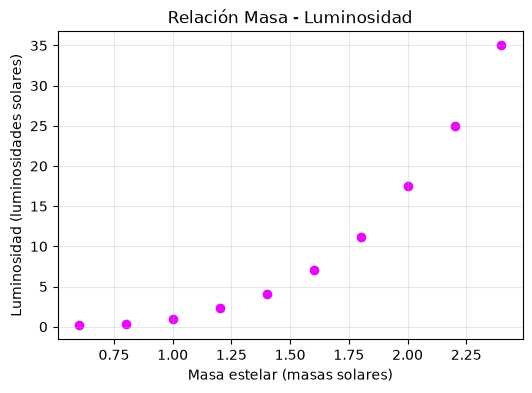

In [78]:
plt.figure(figsize=(6,4))
plt.scatter(mass, luminosity, color="#E808FC")
plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Relación Masa - Luminosidad")
plt.grid(True, alpha=0.3)
plt.show()

**Lo desarrollado:** se grafica `mass` vs `luminosity` con un diagrama de 
dispersión (celda anterior). A continuación se describe la relación observada 
y se evalúa si una recta sería adecuada.


**2.1 Describir la relación observada.**

La relación entre la masa estelar y la luminosidad es no lineal, para valores entre 0 y 1.50, son más cercanos, despues de este valor los valores suelen ser cada vez más separados, hasta llegar a 35 luminosidades para un valor entre 2.25 y 2.50.

**2.2 Explicar si una línea recta es adecuada y dónde podrían ocurrir errores sistemáticos.**

Una linea no es adecuada, ya que no captura bien la curvatura, lo que se puede evidenciar es posiblemnete una polinomica.
Los errores se podrian producir en los extremos y se podrian producir valores no realistas en el contexto.

## 3. Implementar el algoritmo de aprendizaje

- *Crear funciones reutilizables y vectorizadas para:*
  - *Predicción: `y_hat = X @ w + b`.*
  - *Error cuadrático medio, usando la convención vista en clase.*
  - *El gradiente respecto a `w` y `b`.*
  - *Descenso de gradiente, incluyendo un historial del costo durante el entrenamiento.*
- *Las funciones deben soportar matrices de diseño con uno o más features.*


**Lo desarrollado:** se implementan 4 funciones vectorizadas con NumPy, 
reutilizables para cualquier número de features (1 para el modelo lineal, 
2 para el polinómico).

**3.1 Predicción (Hipótesis) $f_{w,b}(x)$**

Para una estrella con un solo feature (masa), el modelo es:
$$f_{w,b}(x) = wx + b$$

Para varios features (por ejemplo, masa y masa²), con $\vec{x} \in \mathbb{R}^n$ 
y $\vec{w} \in \mathbb{R}^n$:
$$f_{\vec{w},b}(\vec{x}) = \sum_{j=1}^{n} w_j x_j + b = \vec{w}^T\vec{x} + b$$

Para todas las estrellas del dataset a la vez, usando la matriz de diseño 
$X \in \mathbb{R}^{m \times n}$ (una fila por estrella, una columna por feature):
$$\hat{y} = Xw + b$$

En NumPy, `X @ w` es la multiplicación matricial que calcula esta suma 
ponderada para todas las estrellas al mismo tiempo.


In [79]:
def predict(X,w,b):
    return X @ w + b

**3.2 Función de costo $J(w,b)$ - Error Cuadrático Medio (vectorizado)**

$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2$$

En forma vectorial, si definimos el vector de error $e = \hat{y} - y$:
$$J(w,b) = \frac{1}{2m}\, e^T e$$

`e @ e` en NumPy es el producto punto de `e` consigo mismo, equivalente a 
sumar `e[i]**2` para todas las estrellas.


In [80]:
def compute_cost(X,y,w,b):
    m = X.shape[0]
    y_hat = predict(X,w,b)
    error = y_hat -y
    cost = (error @ error) /(2 * m)

    return cost 

**3.3 Gradiente de la función de costo (derivación)**

Antes de escribir el código, derivamos el gradiente paso a paso.

Para el feature $j$, la predicción de la estrella $i$ es:
$$\hat{y}^{(i)} = w_1x_1^{(i)} + w_2x_2^{(i)} + \cdots + w_nx_n^{(i)} + b$$

Definimos el error de la estrella $i$ como $e^{(i)} = \hat{y}^{(i)} - y^{(i)}$, 
así que el costo queda:
$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(e^{(i)}\right)^2$$

Derivando respecto a $w_j$ con la regla de la cadena:
$$\frac{\partial J}{\partial w_j} = \frac{1}{2m}\sum_{i=1}^{m} 2\,e^{(i)}\,\frac{\partial e^{(i)}}{\partial w_j}$$

Como $y^{(i)}$ no depende de $w_j$, y en $\hat{y}^{(i)}$ solo el término 
$w_jx_j^{(i)}$ cambia con $w_j$:
$$\frac{\partial e^{(i)}}{\partial w_j} = \frac{\partial \hat{y}^{(i)}}{\partial w_j} = x_j^{(i)}$$

El 2 se cancela con el $\frac{1}{2m}$, quedando:
$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m} e^{(i)} x_j^{(i)}$$

Para el sesgo $b$, como $\frac{\partial \hat{y}^{(i)}}{\partial b} = 1$:
$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} e^{(i)}$$

**En forma matricial:** con $e = \hat{y} - y$, la matriz $X$ tiene una fila 
por estrella y una columna por feature. Al calcular $X^T e$, cada columna de 
feature se multiplica por el vector de error y se suma — esto da todos los 
gradientes de `w` a la vez:
$$\nabla_w J(w,b) = \frac{1}{m}X^T e, \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} e^{(i)}$$

En NumPy:
```python
dw = (X.T @ error) / m
db = np.sum(error) / m
```


**3.4 Implementación del gradiente**


In [81]:
def compute_gradient(X,y,w,b):
    m = X.shape[0]
    y_hat = predict(X,w,b)
    error = y_hat -y

    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

**3.5 Descenso de gradiente**

En cada iteración:
1. Se calcula $\hat{y} = f_{w,b}(X)$.
2. Se calculan los gradientes $\nabla_w J$ y $\frac{\partial J}{\partial b}$.
3. Se actualizan los parámetros:
$$w := w - \alpha \nabla_w J, \qquad b := b - \alpha \frac{\partial J}{\partial b}$$

donde $\alpha$ (`learning_rate`) controla el tamaño del paso. Se repite este 
ajuste muchas veces (iteraciones), guardando el costo en cada paso para poder 
graficar la convergencia después.


**3.6 Implementación del descenso de gradiente**


In [82]:
def gradient_descent(X, y, w_init , b_init, alpha, num_iterations, print_progress = True):
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X,y,w,b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(X,y,w,b)
        history_it.append(i)
        history_cost.append(cost)

        if print_progress and (i % max(1, num_iterations // 10) or i == num_iterations -1):
            print(f"Iteración {i:5d}: Costo {cost:10.4f}")

    return w, b, history_it, history_cost

## 4. Entrenar el modelo lineal

- *Usar la representación: `X_linear = [mass]`.*
- *Inicializar los parámetros.*
- *Elegir una tasa de aprendizaje y número de iteraciones.*
- *Entrenar el modelo.*
- *Graficar el costo contra la iteración.*
- *Graficar la recta ajustada junto con las observaciones.*
- *Reportar los parámetros finales y el costo.*
- *Diagnosticar la convergencia y los errores sistemáticos.*


In [ ]:
X_linear = mass.reshape(-1, 1)
print("X_linear shape:", X_linear.shape)

# 4.2 inicializamos los parametros
w_init = np.zeros(1)
b_init = 0.0

# 4.3 Elegimos la tasa de aprendizaje e iteraciones
learning_rate = 0.01
iterations = 10000

# 4.4 Entrenar
w_lin, b_lin, it_lin, cost_lin = gradient_descent(X_linear, luminosity, w_init, b_init, learning_rate, iterations)

print("w final: ", w_lin)
print("b final: ", b_lin)
print("Costo final: ", cost_lin[-1])


X_linear shape: (10, 1)
Iteración     1: Costo   106.8632
Iteración     2: Costo   101.9913
Iteración     3: Costo    97.4498
Iteración     4: Costo    93.2159
Iteración     5: Costo    89.2687
Iteración     6: Costo    85.5885
Iteración     7: Costo    82.1571
Iteración     8: Costo    78.9573
Iteración     9: Costo    75.9734
Iteración    10: Costo    73.1905
Iteración    11: Costo    70.5949
Iteración    12: Costo    68.1738
Iteración    13: Costo    65.9152
Iteración    14: Costo    63.8080
Iteración    15: Costo    61.8418
Iteración    16: Costo    60.0070
Iteración    17: Costo    58.2947
Iteración    18: Costo    56.6963
Iteración    19: Costo    55.2042
Iteración    20: Costo    53.8109
Iteración    21: Costo    52.5099
Iteración    22: Costo    51.2947
Iteración    23: Costo    50.1596
Iteración    24: Costo    49.0989
Iteración    25: Costo    48.1077
Iteración    26: Costo    47.1811
Iteración    27: Costo    46.3148
Iteración    28: Costo    45.5046
Iteración    29: Costo  

**Lo desarrollado:** se construye `X_linear` con la sola columna `mass`, se 
inicializan `w` y `b` en cero, se eligen `learning_rate` e `iterations`, y se 
entrena reutilizando `gradient_descent`. Los resultados (celda anterior) 
muestran los parámetros finales y el costo final.


**4.5 Graficar el costo contra la iteración.**


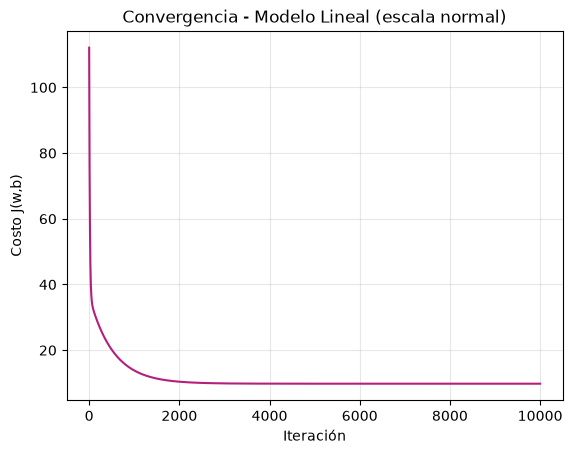

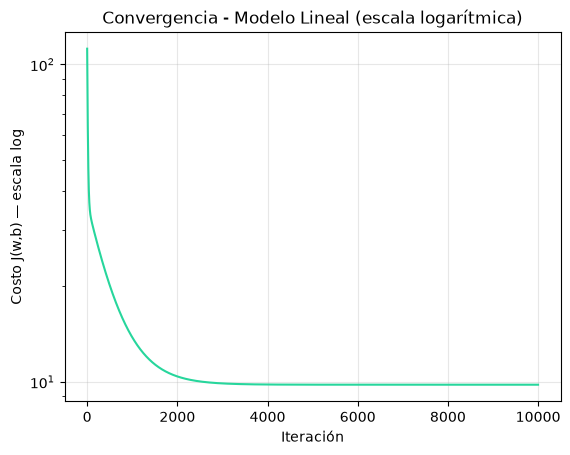

In [84]:
plt.figure()
plt.plot(it_lin, cost_lin, color="#B41F7D")
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b)")
plt.title("Convergencia - Modelo Lineal (escala normal)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.semilogy(it_lin, cost_lin, color="#27D69C")
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b) — escala log")
plt.title("Convergencia - Modelo Lineal (escala logarítmica)")
plt.grid(True, alpha=0.3)
plt.show()

Estas graficas nos muestran como va bajando la cantidad de errores a medida que pasa las iteraciones, el eje X nos muestra el descenso del gradiente y el eje Y, nos dice que tan mal se esta prediciendo el modelo en esa iteración.

Al principio como pusimos la "w" y "b" en 0, el modelo no sabia nada por lo que el costo era muy alto, luego en las iteraciones entre (0,2100) aproximadamente, se evidencia que ya esta aprendiendo el modelo esto se evidencia porque el costo es cada vez menor en cada iteracion.

Cuando llega a la iteración 2100 aproximadamente vemos que se estabiliza la curva en 10, lo cual nos da como indicio que convergio.

**4.6 Modelo lineal ajustado sobre los datos**

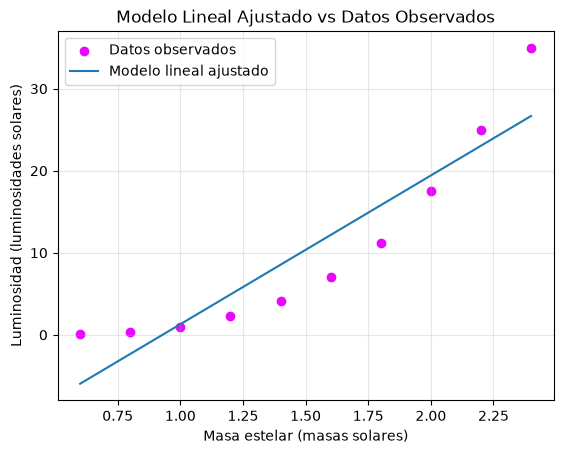

In [85]:
plt.figure()
plt.scatter(mass, luminosity, color="#E808FC", label="Datos observados")

mass_range = np.linspace(mass.min(), mass.max(), 100).reshape(-1, 1)
luminosity_pred = predict(mass_range, w_lin, b_lin)

plt.plot(mass_range, luminosity_pred, color ="#1F77B4",label="Modelo lineal ajustado")

plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Modelo Lineal Ajustado vs Datos Observados")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**4.7 Reporte final y diagnóstico**

- *w final:*  [18.12935781]
- *b final:*  -16.833888424078236
- *Costo final:* ≈ 10

**4.8 Diagnóstico de convergencia y errores sistemáticos**

El descenso de gradiente convergió correctamente: el costo bajó de forma monótona(sin oscilaciones) desde ~100 hasta estabilizarse en ~10 alrededor de la iteración 2100, confirmado tanto en escala normal como logarítmica.

Aunque el modelo captura la tendencia general, se observa que para masas altas la luminosidad crece más rápido que la recta ajustada. Esto provoca que el modelo lineal subestime la luminosidad en los valores más grandes y no represente adecuadamente la curvatura de los datos. Esto sugiere que una regresión polinómica sería más apropiada para este conjunto de datos.

## 5. Entrenar el modelo polinómico

- *Crear la representación: `X_polynomial = [mass, mass²]`.*
- *Reutilizar las mismas funciones de predicción, costo, gradiente y descenso de gradiente.*
- *Entrenar el modelo.*
- *Graficar su convergencia.*
- *Graficar la curva ajustada junto con las observaciones.*
- *Reportar los parámetros finales y el costo.*
- *Explicar qué cambió en el modelo y qué se mantuvo sin cambios.*

Se desarrollan dos variantes para comparar el efecto del escalamiento de 
features: **sin escalar** y **con escalar**.


#### **Modelo polinómico - sin escalar**

Construimos la matriz de diseño con dos columnas: `mass` y `mass²`.

In [ ]:
#4.1 X_polynomial has 2 columns: mass and mass^2.
X_poly = np.column_stack([mass, mass**2])

# Inicializamos los parámetros en cero, igual que hicimos para el modelo lineal.
w_init_poly = np.zeros(2) #dos valores uno por cada mass, mass**2
b_init_poly = 0.0

#Entrenamos con las mismas funciones que en lineal

learning_rate_poly = 0.01
iterations_poly = 10000
#4.3 Entrenamos el modelo
w_poly, b_poly, it_poly, cost_poly = gradient_descent(X_poly, luminosity, w_init_poly, b_init_poly, learning_rate_poly, iterations_poly)

print("w final:", w_poly)
print("b final:", b_poly)
print("Costo final:", cost_poly[-1])

Iteración     1: Costo    73.5670
Iteración     2: Costo    59.1076
Iteración     3: Costo    48.1240
Iteración     4: Costo    39.7763
Iteración     5: Costo    33.4278
Iteración     6: Costo    28.5953
Iteración     7: Costo    24.9126
Iteración     8: Costo    22.1021
Iteración     9: Costo    19.9529
Iteración    10: Costo    18.3055
Iteración    11: Costo    17.0387
Iteración    12: Costo    16.0606
Iteración    13: Costo    15.3017
Iteración    14: Costo    14.7089
Iteración    15: Costo    14.2424
Iteración    16: Costo    13.8718
Iteración    17: Costo    13.5739
Iteración    18: Costo    13.3314
Iteración    19: Costo    13.1309
Iteración    20: Costo    12.9625
Iteración    21: Costo    12.8184
Iteración    22: Costo    12.6930
Iteración    23: Costo    12.5819
Iteración    24: Costo    12.4817
Iteración    25: Costo    12.3898
Iteración    26: Costo    12.3045
Iteración    27: Costo    12.2241
Iteración    28: Costo    12.1477
Iteración    29: Costo    12.0744
Iteración    3

**4.4 Convergencia (costo vs iteración)**


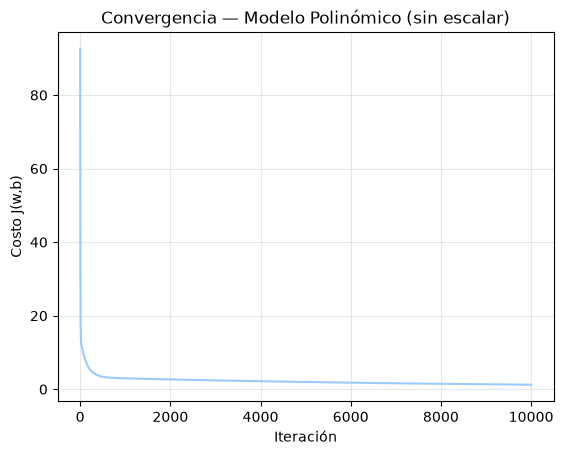

In [ ]:
plt.figure()
plt.plot(it_poly, cost_poly, color="#9CCAFB")
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b)")
plt.title("Convergencia - Modelo Polinómico (sin escalar)")
plt.grid(True, alpha=0.3)
plt.show()

**4.5 Curva ajustada sobre los datos observados**


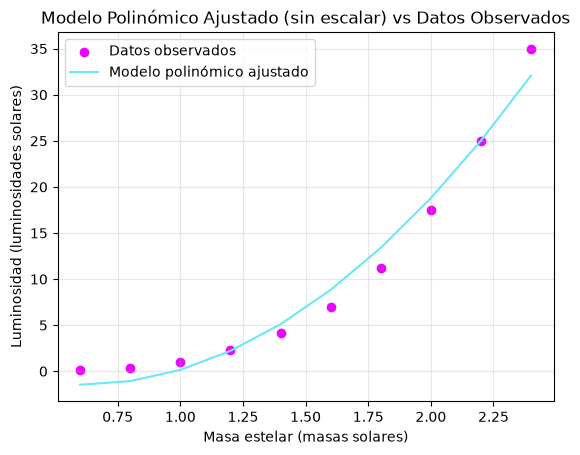

In [88]:
plt.figure()
# Datos originales

plt.scatter(mass, luminosity, color="#E808FC", label="Datos observados")
mass_grid = np.linspace(mass.min(), mass.max(), 200)
X_grid = np.column_stack([mass_grid, mass_grid**2])

luminosity_pred_poly = predict(X_poly, w_poly, b_poly)

plt.plot(mass, luminosity_pred_poly, color="#6be7fa", label="Modelo polinómico ajustado")

plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Modelo Polinómico Ajustado (sin escalar) vs Datos Observados")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### **Modelo polinómico - con escalar**

Estandarizamos cada feature (media 0, desviación estándar 1) antes de entrenar, 
siguiendo la misma técnica del taller de multi-feature regression.

### ¿Por qué escalar?

Cuando los features tienen escalas muy distintas, el descenso de gradiente 
puede volverse lento o inestable. La estandarización centra cada feature en 
media 0 y desviación estándar 1:
$$x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$


In [89]:
# calcula la media y desviación estándar de cada columna
#  de X (mass y mass² por separado)
def feature_scale(X):
    """Standardize each feature to have mean 0 and standard deviation 1."""
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds

In [90]:
#Escalamos los datos polinómicos
X_poly_scaled, means_poly, stds_poly = feature_scale(X_poly)

w_init_poly_scaled = np.zeros(2) #dos valores uno por cada mass, mass**2
b_init_poly_scaled = 0.0

learning_rate_poly_s = 0.1
iterations_poly_s = 10000

w_poly_s, b_poly_s, it_poly_s, cost_poly_s = gradient_descent(X_poly_scaled, luminosity, w_init_poly_scaled, b_init_poly_scaled, learning_rate_poly_s, iterations_poly_s)

print("w final:", w_poly_s)
print("b final:", b_poly_s)
print("Costo final:", cost_poly_s[-1])

Iteración     1: Costo    65.3091
Iteración     2: Costo    50.0887
Iteración     3: Costo    39.1854
Iteración     4: Costo    31.2680
Iteración     5: Costo    25.4409
Iteración     6: Costo    21.0963
Iteración     7: Costo    17.8170
Iteración     8: Costo    15.3138
Iteración     9: Costo    13.3834
Iteración    10: Costo    11.8811
Iteración    11: Costo    10.7025
Iteración    12: Costo     9.7713
Iteración    13: Costo     9.0311
Iteración    14: Costo     8.4394
Iteración    15: Costo     7.9642
Iteración    16: Costo     7.5808
Iteración    17: Costo     7.2701
Iteración    18: Costo     7.0173
Iteración    19: Costo     6.8108
Iteración    20: Costo     6.6413
Iteración    21: Costo     6.5015
Iteración    22: Costo     6.3856
Iteración    23: Costo     6.2891
Iteración    24: Costo     6.2080
Iteración    25: Costo     6.1395
Iteración    26: Costo     6.0812
Iteración    27: Costo     6.0310
Iteración    28: Costo     5.9875
Iteración    29: Costo     5.9494
Iteración    3

**4.4 Convergencia (costo vs iteración) - Escalada**


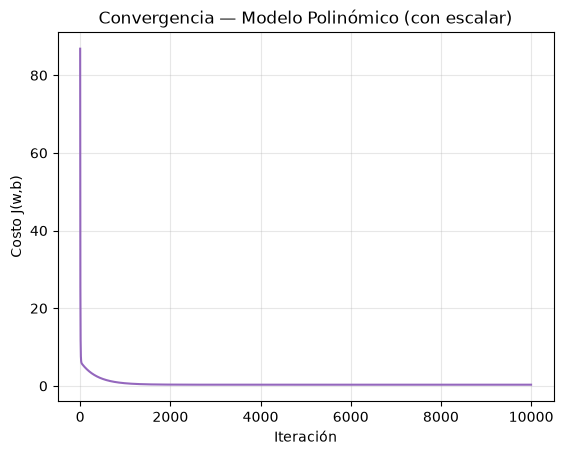

In [91]:
plt.figure()
plt.plot(it_poly_s, cost_poly_s, color="#9467BD")
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b)")
plt.title("Convergencia — Modelo Polinómico (con escalar)")
plt.grid(True, alpha=0.3)
plt.show()

**4.5 Curva ajustada sobre los datos observados**


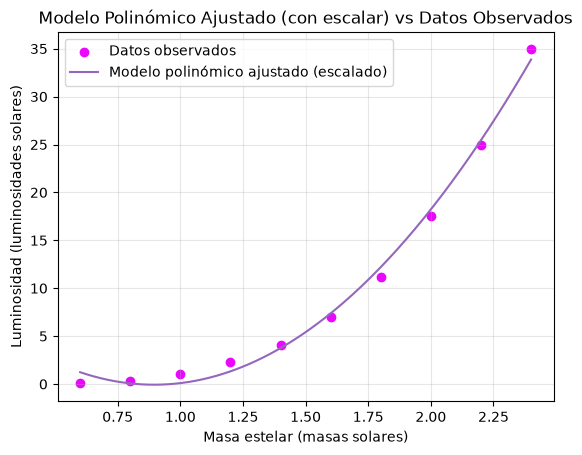

In [92]:
plt.figure()

plt.scatter(mass, luminosity, color="#E808FC", label="Datos observados")

mass_grid = np.linspace(mass.min(), mass.max(), 200)
X_grid = np.column_stack([mass_grid, mass_grid**2])
X_grid_scaled = (X_grid - means_poly) / stds_poly

luminosity_pred_poly_s = predict(X_grid_scaled, w_poly_s, b_poly_s)

plt.plot(mass_grid, luminosity_pred_poly_s, color="#9467BD", label="Modelo polinómico ajustado (escalado)")

plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Modelo Polinómico Ajustado (con escalar) vs Datos Observados")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**4.6 Reporte de parámetros finales y costo**

Sin escalar
 - w_poly: [-12.67469496  10.43731638]
 - b_poly: 2.387663229623036
 - Costo: 1.2311826498945866

Con escalar
 - w_poly: [-15.40280775  26.18248709]
 - b_poly: 10.359999999999989
 - Costo:0.31513333333806876


**4.7 Preguntas**

*¿Qué cambió respecto al modelo lineal?*

- La **representación** de los datos: en vez de usar solo `mass` como feature, ahora usamos `[mass, mass²]`, lo que le da al modelo la capacidad de curvarse en vez de ser una línea recta.
- El número de parámetros en `w`: pasó de 1 valor a 2 valores (uno por cada feature).

*Qué se mantuvo exactamente igual:*
- Las funciones `predict`, `compute_cost`, `compute_gradients` y `gradient_descent` no se modificaron en absoluto — se reutilizaron tal cual se definieron en el Punto 3.
- El proceso de entrenamiento (inicializar en cero, calcular gradientes, actualizar parámetros, repetir) es idéntico conceptualmente al del modelo lineal.

Esto demuestra que el mismo algoritmo de descenso de gradiente puede ajustar modelos de distinta complejidad (lineal o polinómico) simplemente cambiando qué información contiene la matriz de diseño X

**Conclusión de las gráficas:**

Las curvas de convergencia muestran que los tres modelos lineal, polinómico sin escalar y polinómico con escalar entrenan de forma 
estable, debido a que poidemos observar que el costo desciende sin oscilaciones ni divergencia y se aplana hacia el final del entrenamiento.

Al comparar las curvas ajustadas contra los datos observados, la diferencia es evidente, el modelo lineal no logra seguir la 
curvatura real de los datos queda claramente por debajo en los extremos y por 
encima en el rango medio, mientras que ambas versiones del modelo polinómico 
siguen la forma de los datos de manera mucho más cercana en todo el rango observado.

Entre las dos versiones polinómicas, la curva con escalar se ajusta 
visualmente un poco mejor en el extremo de masa baja, esto es consistente con la diferencia de los valores de los costos, la grafica escalada permitio que se acercara más al minimo con el mismo numero de iteraciones, porque al escalar los features pudimos usar una tasa de aprendizaje más grande.

En conclusión, agregar `mass²` como feature mejora la representación de la relación real entre masa y luminosidad y que el escalamiento de features, 
aunque en este caso noi es necesario para lograr convergencia, 
sí produce un mejor ajuste dentro del mismo numero de iteraciones.

## 6. Comparar los modelos

- *Comparar los costos finales.*
- *Graficar o inspeccionar de otra forma los residuos de ambos modelos.*
- *Mostrar ambos modelos ajustados junto con las observaciones.*
- *Explicar cuál modelo representa mejor el rango observado y por qué.*
- *No concluir que un menor error de entrenamiento por sí solo prueba validez científica.*


**6.1 Comparar los costos finales**

El modelo polinómico con escalar logra el menor costo (0.315), seguido del 
polinómico sin escalar (1.231), y muy por encima el modelo lineal (9.795). 
Esto confirma que agregar `mass²` como feature mejora el 
ajuste, y que el escalamiento aporta una mejora adicional dentro del mismo 
número de iteraciones.

In [ ]:
print("Costo final - Modelo lineal:", cost_lin[-1])
print("Costo final - Modelo polinómico (sin escalar):", cost_poly[-1])
print("Costo final - Modelo polinómico (con escalar):", cost_poly_s[-1])

Costo final - Modelo lineal: 9.79514864326178
Costo final - Modelo polinómico (sin escalar): 1.2311826498945866
Costo final - Modelo polinómico (con escalar): 0.31513333333806876


**Lo desarrollado:** se imprimen los costos finales de los tres modelos 
entrenados (lineal, polinómico sin escalar, polinómico con escalar) para 
compararlos numéricamente.


**6.2 Graficar o inspeccionar de otra forma los residuos de ambos modelos.**


In [ ]:
residuals_lin = luminosity - predict(X_linear, w_lin, b_lin)
residuals_poly = luminosity - predict(X_poly_scaled, w_poly_s, b_poly_s)

print("Residuos modelo lineal:", residuals_lin)
print("Residuos modelo polinómico:", residuals_poly)

Residuos modelo lineal: [ 6.10627374  2.68040218 -0.29546938 -2.62134094 -4.4472125  -5.17308407
 -4.59895563 -1.92482719  1.94930125  8.32342969]
Residuos modelo polinómico: [-1.0836309   0.28424443  0.90363574  0.97454306  0.34696637 -0.37909433
 -1.00363903 -0.72666773 -0.44818044  1.13182284]


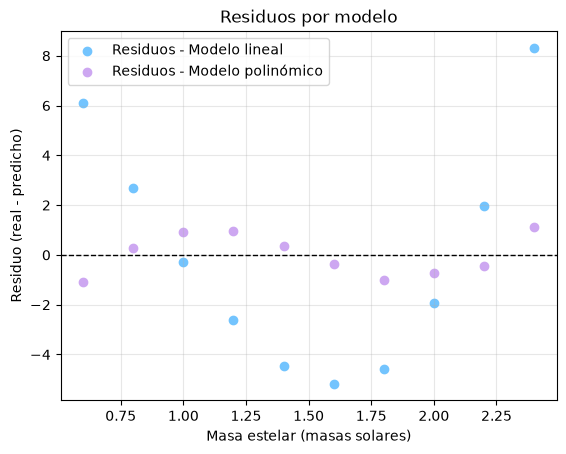

In [96]:
plt.figure()
plt.scatter(mass, residuals_lin, color="#73C4FE", label="Residuos - Modelo lineal")
plt.scatter(mass, residuals_poly, color="#CDA7F1", label="Residuos - Modelo polinómico")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Residuo (real - predicho)")
plt.title("Residuos por modelo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**6.3 Modelos ajustados junto a las observaciones**


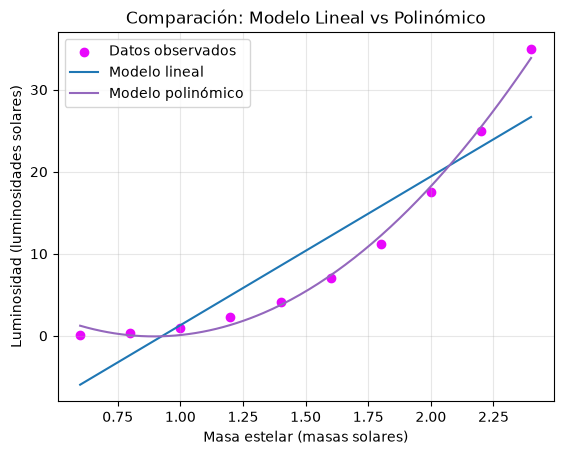

In [98]:
plt.figure()

# Datos originales
plt.scatter(mass, luminosity, color="#E808FC", label="Datos observados")

# modelo lineal.
mass_grid = np.linspace(mass.min(), mass.max(), 200)
X_grid_lin = mass_grid.reshape(-1, 1)
pred_lin_grid = predict(X_grid_lin, w_lin, b_lin)
plt.plot(mass_grid, pred_lin_grid, color="#1F77B4", label="Modelo lineal")

# Curva polinomial.
X_grid_poly = np.column_stack([mass_grid, mass_grid**2])
X_grid_poly_scaled = (X_grid_poly - means_poly) / stds_poly
pred_poly_grid = predict(X_grid_poly_scaled, w_poly_s, b_poly_s)
plt.plot(mass_grid, pred_poly_grid, color="#9467BD", label="Modelo polinómico")

plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Comparación: Modelo Lineal vs Polinómico")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**6.4 ¿Cuál modelo representa mejor el rango observado?**

El modelo polinómico representa mucho mejor el rango observado, lo podemos evidenciar por los siguientes aspectos:

1. **Costo final:** el polinómico alcanza un costo menor (0.3151) que el lineal (9.80), evidenciando que se acerca más al valor minimo.
2. **Forma de la curva:** el polinómico logra seguir el crecimiento acelerado 
de los datos, mientras que la recta del modelo lineal subestima los extremos y sobreestima en la zona media.
3. **Residuos:** los residuos del modelo polinómico están más cerca de cero que los del modelo lineal en todo el rango, confirmando que los errores que cometio son más pequeños punto por punto.


**6.5 No concluir que un menor error de entrenamiento por sí solo prueba validez científica.**

Aunque el modelo polinómico ajusta mejor los 10 puntos observados, esto no 
prueba que sea el modelo "científicamente correcto" para describir la relación masa-luminosidad en general. Un menor costo de entrenamiento solo indica que el modelo se ajusta mejor a estos datos específicos podría estar sobreajustando.

## 7. Probar los límites de la evidencia

- *Generar predicciones de ambos modelos para:*
  - *mass = 1.3, dentro del rango observado.*
  - *mass = 5.0, muy fuera del rango observado.*
- *Comparar los resultados y explicar si los datos disponibles justifican confiar en cada predicción.*


In [99]:
mass_test = np.array([1.3, 5.0])

#Lineal
X_test_lin = mass_test.reshape(-1, 1)
pred_test_lin = predict(X_test_lin, w_lin, b_lin)

#Polinómico
X_test_poly = np.column_stack([mass_test, mass_test**2])
X_test_poly_scaled = (X_test_poly - means_poly) / stds_poly
pred_test_poly = predict(X_test_poly_scaled, w_poly_s, b_poly_s)

for i, m in enumerate(mass_test):
    print(f"mass = {m}")
    print(f"  Predicción modelo lineal:     {pred_test_lin[i]:.3f}")
    print(f"  Predicción modelo polinómico: {pred_test_poly[i]:.3f}")
    print()

mass = 1.3
  Predicción modelo lineal:     6.734
  Predicción modelo polinómico: 2.389

mass = 5.0
  Predicción modelo lineal:     73.813
  Predicción modelo polinómico: 252.390



**7.2 Comparación de resultados:**

| mass | Modelo lineal | Modelo polinómico |
|------|---------------|--------------------|
| 1.3  | 6.734         | 2.389              |
| 5.0  | 73.813        | 252.390            |

*En mass = 1.3 (dentro del rango):* el modelo polinómico (2.389) es más 
coherente con los datos reales cercanos (2.30 en mass=1.2, 4.10 en mass=1.4) 
que el lineal (6.734), que se aleja bastante.

*En mass = 5.0 (fuera del rango):* las predicciones son muy distintas 
(73.8 vs 252.4) porque no teníamos una estrella tan grande en el arreglo. 
El modelo sigue aplicando su fórmula, pero nada nos asegura que siga siendo 
válida en ese punto.

*¿Se puede confiar en estas predicciones?*

En mass = 1.3: sí, porque está dentro del rango de datos que ya conocíamos (entre 0.6 y 2.4).

En mass = 5.0: no, porque está muy lejos de cualquier dato real que tengamos.
El modelo solo está inventando el resultado siguiendo su propia fórmula, sin 
ninguna estrella real que confirme si ese número tiene sentido.


## 8. Reflexionar sobre Inteligencia Artificial

- What does this regression experiment reveal—and what does it fail to reveal—about how more advanced AI systems learn?

Este ejercicio me mostró de forma muy clara la idea básica detrás de cómo 
"aprende" una IA: empieza sin saber nada, va probando, se equivoca, corrige y repite eso muchas veces hasta acercarse a la respuesta correcta. 
Verlo funcionar con mis propios números me ayudó a entender que la IA se hace realmente con solo matemáticas ajustándose paso a paso.

Aunque realmente la mayoria de veces nosotros le pasamos un texto completo, esto es más complejo de lo que en este trabajo se desarrollo, aqui solo entendia una relacion entre masa y luminosidad, sin embargo, la idea base es la misma.

- Do you think Artificial General Intelligence is achievable? Explain what you understand by AGI and why you believe it is—or is not—reachable.

La AGI, es una inteligencia que pueda replicar el cerebro humano, sus formas de aprender y de generar conocimiento por si mismo din tener fuentes donde leer, como lo hace actualmente.

Considero que si puede llegar a ser posible, a un largo plazo, y de pronto mezclando las formas de aprendizaje como el que ya tiene que es con muchas fuentes como lo hace un cerebro leyendo varios libros e investigando pero tambien tendria que tener una exploracion de mundo, algo mas empirico.

- Could AGI emerge primarily by scaling neural networks with more GPUs, data, and parameters? Or will it require fundamentally different architectures, learning mechanisms, theories, or ways of interacting with the world?

Considero que aumentar estos factores como parametros, GPUs o data, simplemente mejorarian sus respuestas, ya que tienen mas capacidad de realizar calculo matematicos o estadisticos, pero para llegar a AGI, necesitamos que aprenda de otra forma como lo hace el cerebro humano constantemente, que tenga cirta capacidad para medir el peligro de hacer algo, que tenga curiosidad como un humano que es el factor principal que impulsa tener conocimento.

- One question about AI-driven systems that I want to explore during the semester is: Quiero saber cómo se puede reducir el impacto ambiental de la IA, y si esta puede ayudar a mitigar el consumo de energía.
